In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [2]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# Load data

In [4]:
data_uv = pd.read_csv('data/uv_spectra_synth.csv').dropna()
data_uv.describe()

,group id,cell type,1,2,3,4,5,6,7,8,...,476,477,478,479,480,481,482,483,484,485
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,...,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,13.474667,1.000000,0.483245,0.475828,0.467839,0.459083,0.450360,0.441018,0.434649,0.431430,...,0.357790,0.367879,0.369229,0.360687,0.348383,0.336454,0.329135,0.330481,0.335602,0.342518
std,7.992910,0.816769,0.206713,0.197827,0.188449,0.184008,0.183860,0.179746,0.170049,0.165387,...,0.127857,0.129672,0.130822,0.128388,0.127969,0.129869,0.129353,0.126505,0.128329,0.133457
min,0.000000,0.000000,0.000334,0.001188,0.000863,0.000765,0.001934,0.005940,0.001913,0.000881,...,0.006732,0.018640,0.000234,0.003123,0.021610,0.002543,0.000910,0.002260,0.001319,0.008775
25%,7.000000,0.000000,0.361645,0.352957,0.354239,0.341779,0.331815,0.314295,0.315052,0.319229,...,0.267501,0.273324,0.277126,0.267596,0.258697,0.248257,0.245470,0.244294,0.243966,0.248413
50%,14.000000,1.000000,0.484138,0.471832,0.464575,0.451882,0.446710,0.439509,0.430073,0.424460,...,0.354562,0.369465,0.373822,0.362844,0.347294,0.337406,0.327071,0.329902,0.336884,0.343607
75%,20.000000,2.000000,0.618785,0.612405,0.588635,0.579596,0.582110,0.572135,0.548562,0.540791,...,0.440411,0.455750,0.463369,0.451177,0.435250,0.425700,0.415964,0.411430,0.415430,0.428097
max,28.000000,2.000000,1.007009,0.987126,1.004109,0.989649,0.989619,1.008929,0.977519,0.950136,...,0.835593,0.859693,0.821655,0.799177,0.797731,0.778627,0.757474,0.825323,0.878993,0.890664


In [5]:
data_uv_np = data_uv.to_numpy()

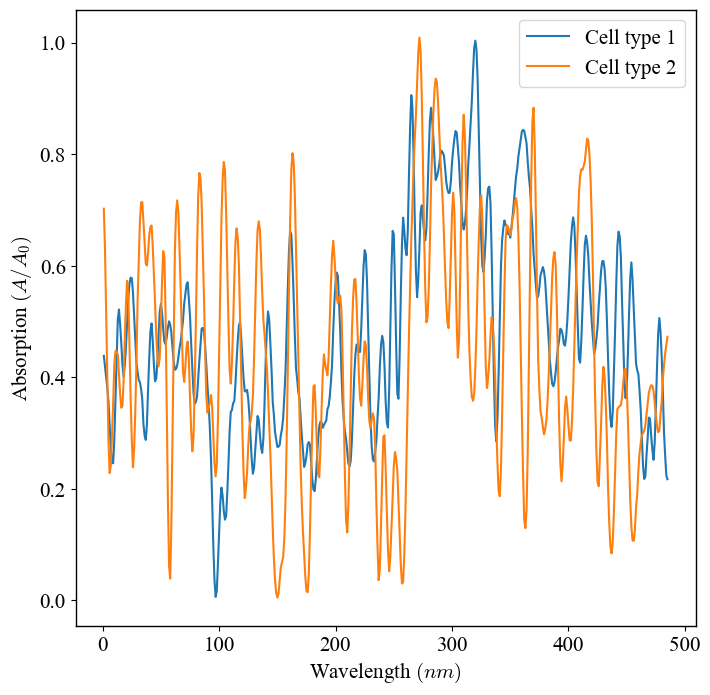

In [7]:
def plot_sample(data):
    '''
    Shows a visualization of the spectroscopic data

    Parameters
    ----------
    data : array
        dataset.

    Returns
    -------
    None.

    '''
    wl = np.linspace(1, 485, 485)
    sample1 = data[1, 2:]
    sample2 = data[623, 2:]
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(wl, sample1, label = 'Cell type 1')
    ax.plot(wl, sample2, label = 'Cell type 2')
    ax.set_xlabel('Wavelength $(nm)$')
    ax.set_ylabel('Absorption $(A/A_{0})$')
    plt.legend()
    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=15
    plt.rcParams['axes.linewidth'] = 1 

    plt.savefig(f'figures/example-9-1-convnet_data.png', dpi = 300)
    plt.show()

plot_sample(data_uv_np)

# Setup convolutional neural network

In [8]:
#Utility functions
def get_device():
    if torch.cuda.is_available():
        device = 'cuda:0'
    else:
        device = 'cpu'
    return device

In [9]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
    
        #Convolutional neural network
        self.conv1 = nn.Conv1d(in_channels = 1, out_channels = 3, kernel_size = 1)
        #self.pool = nn.MaxPool1d(3, stride = 1, padding = 1)
        #self.conv2 = nn.Conv1d(200, 100, 25)
        self.fc1 = nn.Linear(in_features = 3*485, out_features = 500)
        self.fc2 = nn.Linear(in_features = 500, out_features = 250)
        self.fc3 = nn.Linear(in_features = 250, out_features = 3)
    
    def forward(self, x):
        x = self.conv1(x)
        #x = self.pool(F.relu(self.conv1(x)))
        #x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 3*485)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

class Model(Net):
    def __init__(self):
        super(Model, self).__init__()

    #Train 
    def train(self, X_train, y_train):
        self.net = Model()
        epochs = 50
        learning_rate = 0.001
        batch_size = 100
        
        #Define loss function and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.net.parameters(), lr = learning_rate)
        
        device = get_device()
        
        trainset = []
        
        for i in range(len(X_train)):
           trainset.append([X_train[i], y_train[i]])
           
        trainloader = DataLoader(trainset, batch_size = batch_size, shuffle = True)
        
        train_loss = []
        for epoch in range(epochs):
            running_loss = 0.0
            
            for i, data in enumerate(trainloader, 0):
                # get the inputs; data is a list of [inputs, labels]
                x, labels = data
                
                optimizer.zero_grad()
                
                outputs = self.net(x.unsqueeze(1).float())
                
                loss = criterion(outputs, labels.long())
                loss.backward()
                
                optimizer.step()
               
                running_loss += loss.item()
            
            loss = running_loss/len(trainloader)
            train_loss.append(loss)
            print('Epoch {} of {}, Train Loss: {:.3f}'.format(epoch+1, epochs, loss))
        
               
        return train_loss
    
    def predict(self, inputs):
        
        inputs = torch.from_numpy(inputs)
        
        predicted = torch.max(self.net(inputs.unsqueeze(1).float()).data, 1)

        return predicted

# Train model
Predict type for group 3

In [ ]:
err = 0
i = 3

train = data_uv_np[data_uv_np[:, 0] != i]
test = data_uv_np[data_uv_np[:, 0] == i]
X_train, y_train = train[:, 2:], train[:, 1]
X_test, y_test = test[:, 2:], test[:, 1]

m = Model()
loss = m.train(X_train, y_train)

y_pred = m.predict(X_test)
err = np.sum(y_pred != y_test)

total_accuracy = 1 - err/len(data_uv_np)

print(f'Total_accuracy: {total_accuracy:.2f}')

Epoch 1 of 50, Train Loss: 1.105
Epoch 2 of 50, Train Loss: 1.098
Epoch 3 of 50, Train Loss: 1.081
Epoch 4 of 50, Train Loss: 1.040
Epoch 5 of 50, Train Loss: 0.957
Epoch 6 of 50, Train Loss: 0.845
Epoch 7 of 50, Train Loss: 0.816
Epoch 8 of 50, Train Loss: 0.681
Epoch 9 of 50, Train Loss: 0.597
Epoch 10 of 50, Train Loss: 0.626
Epoch 11 of 50, Train Loss: 0.536
Epoch 12 of 50, Train Loss: 0.475
Epoch 13 of 50, Train Loss: 0.558
Epoch 14 of 50, Train Loss: 0.399
Epoch 15 of 50, Train Loss: 0.381
Epoch 16 of 50, Train Loss: 0.386
Epoch 17 of 50, Train Loss: 0.362
Epoch 18 of 50, Train Loss: 0.336
Epoch 19 of 50, Train Loss: 0.298
Epoch 20 of 50, Train Loss: 0.287
Epoch 21 of 50, Train Loss: 0.349
Epoch 22 of 50, Train Loss: 0.336
Epoch 23 of 50, Train Loss: 0.337
Epoch 24 of 50, Train Loss: 0.309
Epoch 25 of 50, Train Loss: 0.313
Epoch 26 of 50, Train Loss: 0.273
Epoch 27 of 50, Train Loss: 0.272
Epoch 28 of 50, Train Loss: 0.286
Epoch 29 of 50, Train Loss: 0.256
Epoch 30 of 50, Train L

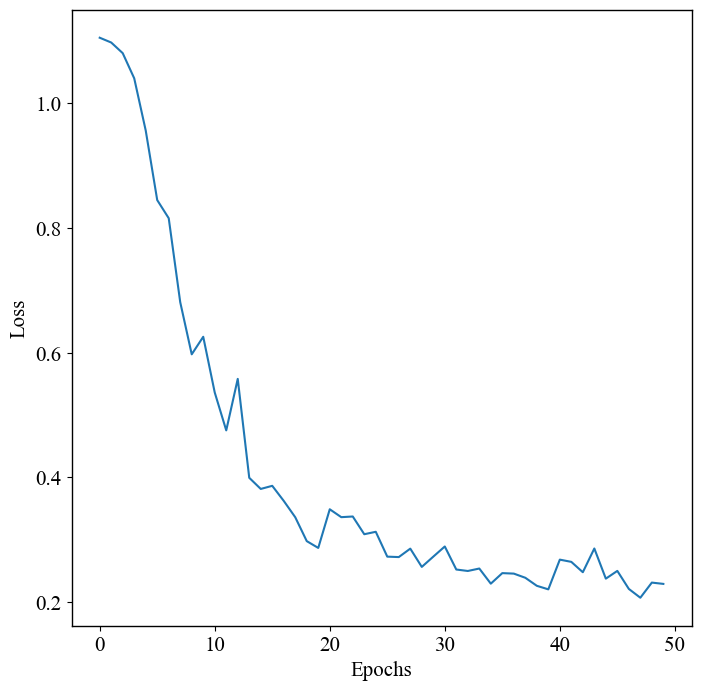

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(loss)

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

plt.savefig(f'figures/example-9-1-convnet_loss.png', dpi = 300)
plt.show()
